# MACHINE LEARNING PROJECT

# FERTILIZER RECOMMENDATION USING SUPERVISED ALOGRITHM

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score
from joblib import dump, load
import warnings
warnings.filterwarnings("ignore")

In [98]:
#k
df=pd.read_csv(r"C:\Users\hp\Downloads\fertilizer_recommendation_dataset (2).csv")
df

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
3095,23.486430,0.531191,46.412228,6.733584,56.534283,146.111078,81.389366,1.602913,Neutral Soil,watermelon,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3096,24.289508,0.736699,63.068103,6.372709,56.358005,49.003277,46.695889,1.473656,Peaty Soil,watermelon,DAP,"Rich in phosphorus, essential for root develop..."
3097,23.945488,0.520513,41.344590,7.051515,55.738905,148.567285,90.057021,1.455045,Neutral Soil,watermelon,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3098,26.368604,0.547436,33.106012,6.615922,57.711705,96.662953,59.531473,0.614487,Acidic Soil,watermelon,Compost,Enhances organic matter and improves soil stru...


# Exploratory Data Analysis

In [99]:
df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [100]:
df.tail()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
3095,23.486430,0.531191,46.412228,6.733584,56.534283,146.111078,81.389366,1.602913,Neutral Soil,watermelon,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3096,24.289508,0.736699,63.068103,6.372709,56.358005,49.003277,46.695889,1.473656,Peaty Soil,watermelon,DAP,"Rich in phosphorus, essential for root develop..."
3097,23.945488,0.520513,41.344590,7.051515,55.738905,148.567285,90.057021,1.455045,Neutral Soil,watermelon,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3098,26.368604,0.547436,33.106012,6.615922,57.711705,96.662953,59.531473,0.614487,Acidic Soil,watermelon,Compost,Enhances organic matter and improves soil stru...
3099,27.670724,0.558722,50.670082,8.828433,59.967605,78.787005,45.327125,1.472728,Acidic Soil,watermelon,Muriate of Potash,"High potassium content, improves fruit and flo..."


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   object 
 9   Crop         3100 non-null   object 
 10  Fertilizer   3100 non-null   object 
 11  Remark       3100 non-null   object 
dtypes: float64(8), object(4)
memory usage: 290.8+ KB


In [102]:
df.columns

Index(['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous',
       'Potassium', 'Carbon', 'Soil', 'Crop', 'Fertilizer', 'Remark'],
      dtype='object')

In [103]:
df.describe()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
count,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000
mean,27.271096,0.600763,111.024949,6.379775,61.278480,69.582850,69.721167,1.474325
std,9.114450,0.144947,77.151880,0.957103,10.186410,42.226712,35.304241,0.698300
min,4.011486,0.227436,-85.709593,3.448974,35.527718,-37.649739,-20.509108,-0.280560
25%,22.408505,0.493595,61.283985,5.860489,54.835715,43.039260,49.992405,0.956401
50%,26.132938,0.599520,96.485935,6.337308,59.429649,58.205269,58.710808,1.463357
75%,29.987887,0.708575,147.619401,6.899739,65.792790,86.108983,76.318626,2.003534
max,56.653592,0.972361,411.955947,9.562341,98.581039,177.314481,161.067982,3.241984


In [104]:
df.isnull().sum()

Temperature    0
Moisture       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
Fertilizer     0
Remark         0
dtype: int64

In [105]:
df.duplicated().sum()

np.int64(0)

In [106]:
df.shape


(3100, 12)

In [107]:
df.size

37200

In [108]:
df["Fertilizer"].value_counts()

Fertilizer
DAP                           1054
Water Retaining Fertilizer     675
Compost                        375
Muriate of Potash              326
Lime                           181
Balanced NPK Fertilizer        157
Urea                           154
Organic Fertilizer              95
Gypsum                          52
General Purpose Fertilizer      31
Name: count, dtype: int64

# Visualising Using Matplotlib

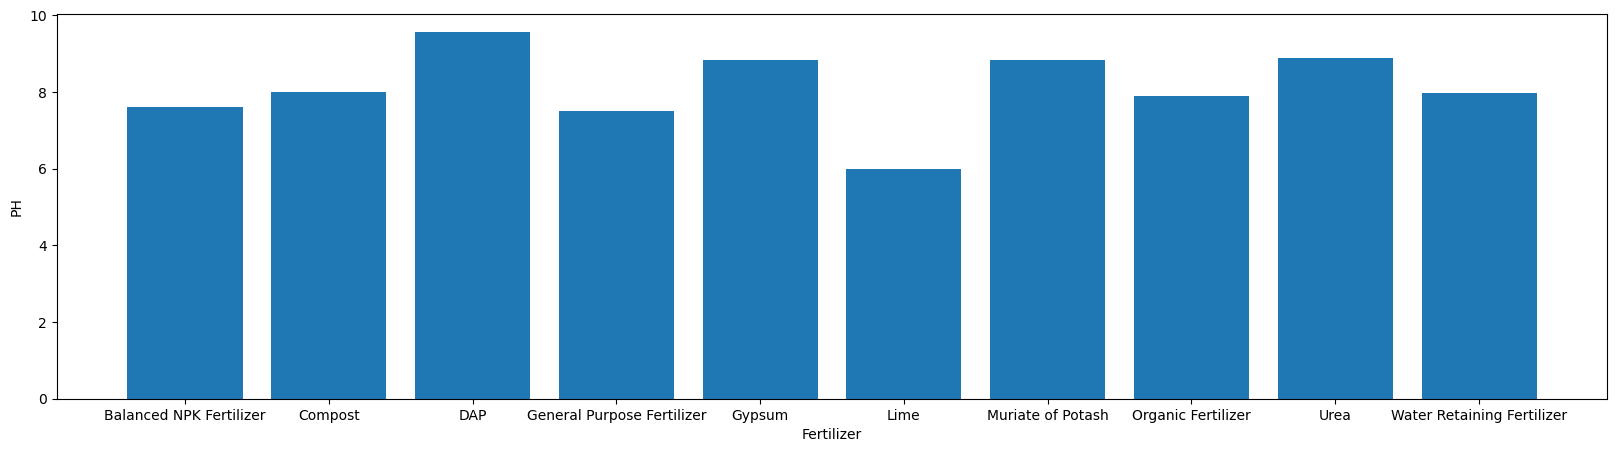

In [109]:
plt.figure(figsize=(20,5))
group=df.groupby("Fertilizer")
grouped=group[["Fertilizer","PH"]].max()
getdata=pd.DataFrame(grouped)
getdata
x=getdata["Fertilizer"].head(10)
y=getdata["PH"].head(10)
plt.bar(x,y)
plt.xlabel("Fertilizer")
plt.ylabel("PH")
plt.show()

# BOX PLOT

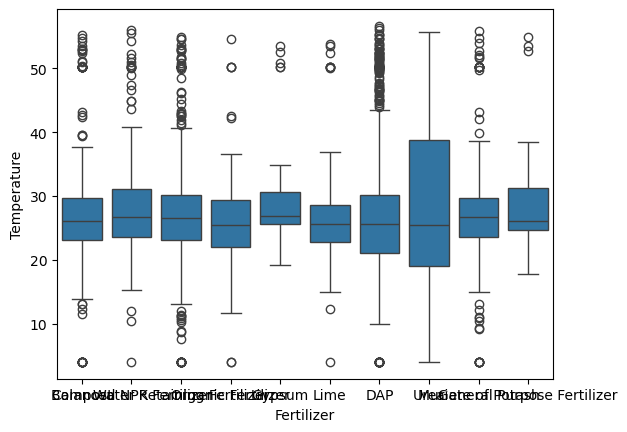

In [110]:
sns.boxplot(x="Fertilizer",y="Temperature",data=df)
plt.show()

# VIOLIN PLOT

<Axes: xlabel='Fertilizer', ylabel='Rainfall'>

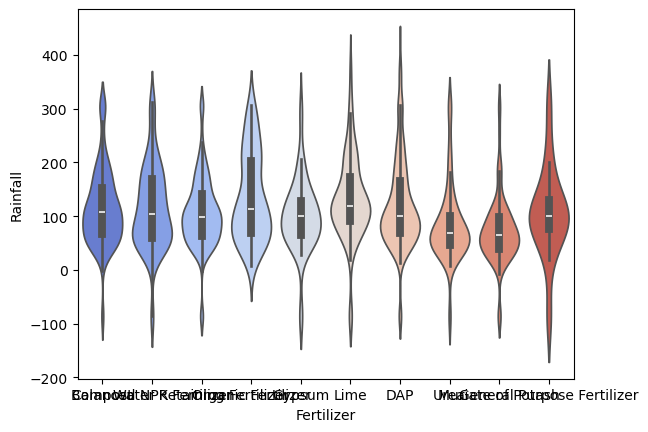

In [111]:
sns.violinplot(x="Fertilizer",y="Rainfall",data=df,palette="coolwarm")


# COMBINING VIOLINPLOT AND SWARMPLOT

<Axes: xlabel='Fertilizer', ylabel='Nitrogen'>

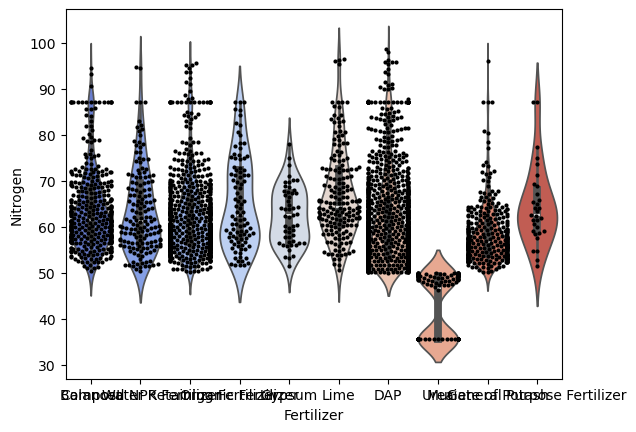

In [112]:
sns.violinplot(x="Fertilizer",y="Nitrogen",data=df,palette="coolwarm")
sns.swarmplot(x="Fertilizer",y="Nitrogen",data=df,color="black",size=3)


# DISPLOT

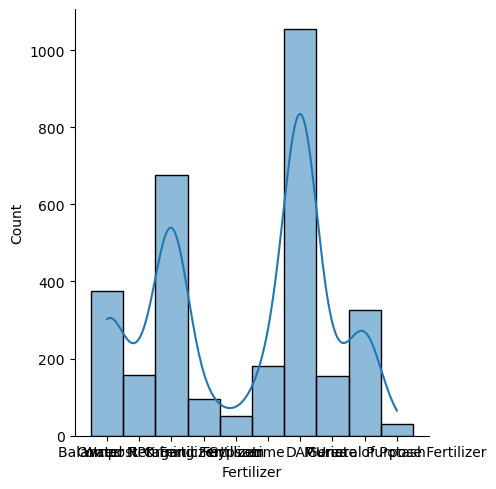

In [113]:
sns.displot(df["Fertilizer"],kde=True)
plt.show()

# Representing the correlation of data values Graphichally

<Axes: >

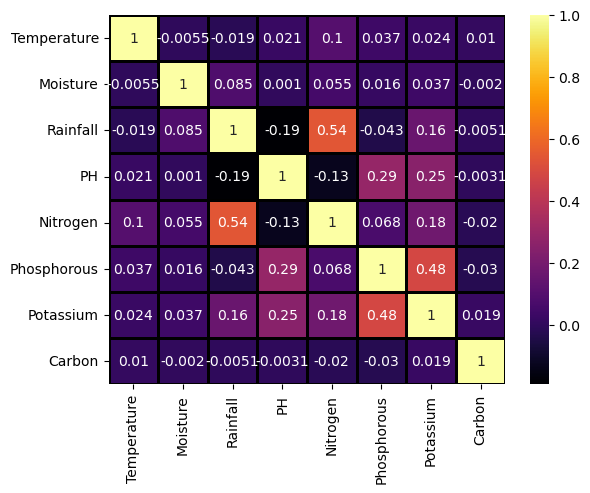

In [114]:
tc=df.corr(numeric_only=True)
sns.heatmap(tc,annot=True,cmap="inferno",linecolor="black",linewidth=2)

# Converting Categorical Values Into Numerical value

In [115]:
l1=LabelEncoder()
l2=LabelEncoder()


In [116]:
df["Soil"]=l1.fit_transform(df["Soil"])
df["Crop"]=l2.fit_transform(df["Crop"])



In [117]:
df

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,2,28,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,2,28,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,4,28,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,2,28,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,4,28,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
3095,23.486430,0.531191,46.412228,6.733584,56.534283,146.111078,81.389366,1.602913,3,29,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3096,24.289508,0.736699,63.068103,6.372709,56.358005,49.003277,46.695889,1.473656,4,29,DAP,"Rich in phosphorus, essential for root develop..."
3097,23.945488,0.520513,41.344590,7.051515,55.738905,148.567285,90.057021,1.455045,3,29,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3098,26.368604,0.547436,33.106012,6.615922,57.711705,96.662953,59.531473,0.614487,0,29,Compost,Enhances organic matter and improves soil stru...


# Selecting Target Value

In [118]:
df.drop("Remark",axis=1,inplace=True)

In [119]:
df

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,2,28,Compost
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,2,28,Balanced NPK Fertilizer
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,4,28,Water Retaining Fertilizer
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,2,28,Balanced NPK Fertilizer
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,4,28,Organic Fertilizer
...,...,...,...,...,...,...,...,...,...,...,...
3095,23.486430,0.531191,46.412228,6.733584,56.534283,146.111078,81.389366,1.602913,3,29,Water Retaining Fertilizer
3096,24.289508,0.736699,63.068103,6.372709,56.358005,49.003277,46.695889,1.473656,4,29,DAP
3097,23.945488,0.520513,41.344590,7.051515,55.738905,148.567285,90.057021,1.455045,3,29,Water Retaining Fertilizer
3098,26.368604,0.547436,33.106012,6.615922,57.711705,96.662953,59.531473,0.614487,0,29,Compost


In [120]:
x=df.drop("Fertilizer",axis=1)
x

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,2,28
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,2,28
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,4,28
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,2,28
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,4,28
...,...,...,...,...,...,...,...,...,...,...
3095,23.486430,0.531191,46.412228,6.733584,56.534283,146.111078,81.389366,1.602913,3,29
3096,24.289508,0.736699,63.068103,6.372709,56.358005,49.003277,46.695889,1.473656,4,29
3097,23.945488,0.520513,41.344590,7.051515,55.738905,148.567285,90.057021,1.455045,3,29
3098,26.368604,0.547436,33.106012,6.615922,57.711705,96.662953,59.531473,0.614487,0,29


In [121]:
y=df["Fertilizer"]
y

0                          Compost
1          Balanced NPK Fertilizer
2       Water Retaining Fertilizer
3          Balanced NPK Fertilizer
4               Organic Fertilizer
                   ...            
3095    Water Retaining Fertilizer
3096                           DAP
3097    Water Retaining Fertilizer
3098                       Compost
3099             Muriate of Potash
Name: Fertilizer, Length: 3100, dtype: object

In [122]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [123]:
scaler=StandardScaler()

In [124]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [125]:
x_test

array([[-0.05687412, -2.58666116,  0.67782237, ..., -0.32556438,
        -0.9279618 , -0.87339128],
       [-0.89249002, -2.58666116,  0.07474042, ..., -0.40263923,
         0.31543252,  1.36343049],
       [ 0.19476908,  0.04239194, -0.61014859, ..., -0.88048244,
         1.55882685, -1.54443782],
       ...,
       [ 0.18015183,  0.14684909,  2.50278127, ...,  1.40784521,
        -0.9279618 ,  0.46870178],
       [-0.79434841, -1.45815691, -0.66037009, ..., -1.20098403,
        -0.30626464, -1.43259673],
       [ 0.44727206, -1.18937837,  0.69632982, ..., -0.33319325,
         0.93712969, -1.20891455]])

In [126]:
x_train.shape

(2170, 10)

In [127]:
y_train.shape

(2170,)

# MODEL-1  LogisticRegression

In [128]:
model1=LogisticRegression()

In [129]:
model1.fit(x_train,y_train)

LogisticRegression()

In [130]:
logtrain=model1.score(x_train,y_train)*100
logtrain

81.38248847926268

In [131]:
logtest=model1.score(x_test,y_test)*100
logtest

79.13978494623656

In [132]:
y_pred1=model1.predict(x_test)
y_pred1

array(['Water Retaining Fertilizer', 'Muriate of Potash', 'Compost',
       'Muriate of Potash', 'DAP', 'DAP', 'DAP', 'Muriate of Potash',
       'DAP', 'Compost', 'Water Retaining Fertilizer', 'Urea', 'DAP',
       'Muriate of Potash', 'Muriate of Potash', 'Organic Fertilizer',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer',
       'Water Retaining Fertilizer', 'DAP', 'Water Retaining Fertilizer',
       'Water Retaining Fertilizer', 'DAP', 'Muriate of Potash',
       'Muriate of Potash', 'Water Retaining Fertilizer',
       'Balanced NPK Fertilizer', 'DAP', 'DAP', 'DAP',
       'Water Retaining Fertilizer', 'Organic Fertilizer', 'DAP',
       'Water Retaining Fertilizer', 'DAP', 'Water Retaining Fertilizer',
       'DAP', 'Water Retaining Fertilizer', 'Water Retaining Fertilizer',
       'DAP', 'Compost', 'DAP', 'DAP', 'Muriate of Potash', 'DAP',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer', 'DAP',
       'DAP', 'Compost', 'Water Retaining Fert

In [133]:
y_test

718     Water Retaining Fertilizer
2953             Muriate of Potash
1805                       Compost
1612             Muriate of Potash
1190                           DAP
                   ...            
2971    Water Retaining Fertilizer
2996                       Compost
2282                           DAP
2170                           DAP
844     Water Retaining Fertilizer
Name: Fertilizer, Length: 930, dtype: object

In [134]:
ac1=accuracy_score(y_test,y_pred1)
ac1

0.7913978494623656

In [135]:
con1=confusion_matrix(y_test,y_pred1)
con1

array([[ 35,   0,   0,   0,   0,   0,   3,   0,   0,   4],
       [  3, 100,   6,   0,   1,   1,   4,   1,   0,   8],
       [  0,   5, 292,   0,   3,   1,   3,   1,   3,   1],
       [  2,   0,   0,   3,   0,   1,   1,   1,   0,   3],
       [  0,   1,   0,   0,   8,   0,   0,   1,   0,   2],
       [  0,   9,  19,   1,   0,  10,   2,   6,   0,   9],
       [  0,   4,  10,   0,   4,   5,  67,   2,   2,   7],
       [  0,   0,   0,   0,   0,   0,   4,  16,   2,   0],
       [  0,   1,  13,   0,   0,   0,   2,   0,  34,   1],
       [  1,   6,  12,   0,   1,   0,   6,   3,   2, 171]])

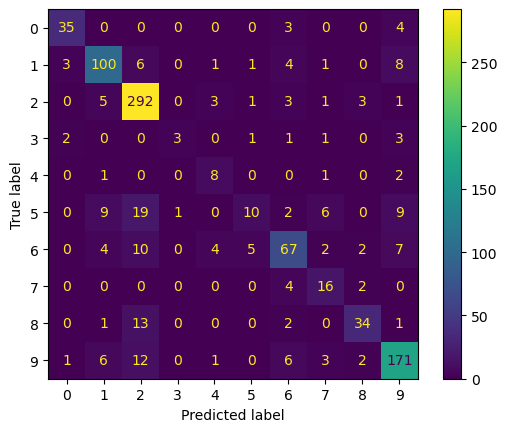

In [136]:
cd1=ConfusionMatrixDisplay(con1)
cd1.plot()

In [137]:
cr1=classification_report(y_test,y_pred1)
print(cr1)

                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       0.85      0.83      0.84        42
                   Compost       0.79      0.81      0.80       124
                       DAP       0.83      0.94      0.88       309
General Purpose Fertilizer       0.75      0.27      0.40        11
                    Gypsum       0.47      0.67      0.55        12
                      Lime       0.56      0.18      0.27        56
         Muriate of Potash       0.73      0.66      0.69       101
        Organic Fertilizer       0.52      0.73      0.60        22
                      Urea       0.79      0.67      0.72        51
Water Retaining Fertilizer       0.83      0.85      0.84       202

                  accuracy                           0.79       930
                 macro avg       0.71      0.66      0.66       930
              weighted avg       0.78      0.79      0.78       930



In [138]:
model1.predict(scaler.transform([[50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,2,28]]))

array(['Compost'], dtype=object)

# MODEL-2 DECISION TREE

In [139]:
model2=DecisionTreeClassifier()

In [140]:
model2.fit(x_train,y_train)

DecisionTreeClassifier()

In [141]:
decisiontrain=model2.score(x_train,y_train)*100
decisiontrain

100.0

In [142]:
decisiontest=model2.score(x_test,y_test)*100
decisiontest

99.35483870967742

In [143]:
y_pred2=model2.predict(x_test)
y_pred2

array(['Water Retaining Fertilizer', 'Muriate of Potash', 'Compost',
       'Muriate of Potash', 'DAP', 'DAP', 'DAP', 'DAP', 'DAP', 'Compost',
       'Water Retaining Fertilizer', 'Urea', 'DAP', 'Compost',
       'Balanced NPK Fertilizer', 'DAP', 'Muriate of Potash',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer',
       'Water Retaining Fertilizer', 'DAP', 'Muriate of Potash', 'Urea',
       'Water Retaining Fertilizer', 'Balanced NPK Fertilizer', 'DAP',
       'DAP', 'Lime', 'Water Retaining Fertilizer', 'Lime', 'DAP',
       'Water Retaining Fertilizer', 'Lime', 'Muriate of Potash', 'DAP',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer', 'DAP',
       'Compost', 'DAP', 'DAP', 'Organic Fertilizer', 'DAP',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer', 'DAP',
       'DAP', 'Compost', 'Lime', 'Balanced NPK Fertilizer', 'DAP', 'DAP',
       'Balanced NPK Fertilizer

In [144]:
y_test

718     Water Retaining Fertilizer
2953             Muriate of Potash
1805                       Compost
1612             Muriate of Potash
1190                           DAP
                   ...            
2971    Water Retaining Fertilizer
2996                       Compost
2282                           DAP
2170                           DAP
844     Water Retaining Fertilizer
Name: Fertilizer, Length: 930, dtype: object

In [145]:
ac2=accuracy_score(y_test,y_pred2)
ac2

0.9935483870967742

In [146]:
con2=confusion_matrix(y_test,y_pred2)
con2

array([[ 42,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, 123,   0,   0,   0,   0,   0,   0,   0,   1],
       [  0,   0, 309,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,  11,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,  12,   0,   0,   0,   0,   0],
       [  0,   0,   1,   0,   0,  55,   0,   0,   0,   0],
       [  0,   1,   0,   0,   0,   0, 100,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  21,   1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   1,  50,   0],
       [  0,   0,   1,   0,   0,   0,   0,   0,   0, 201]])

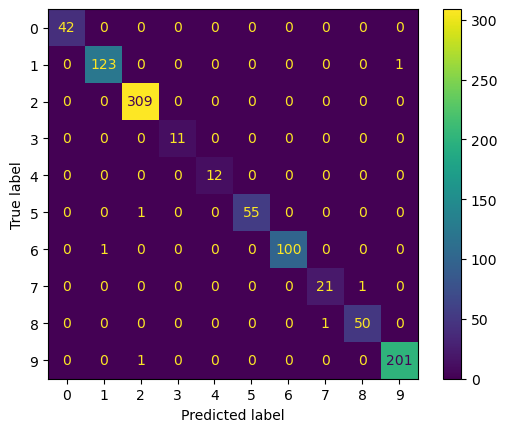

In [147]:
cd2=ConfusionMatrixDisplay(con2)
cd2.plot()

In [148]:
cr2=classification_report(y_test,y_pred2)
print(cr2)

                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       1.00      1.00      1.00        42
                   Compost       0.99      0.99      0.99       124
                       DAP       0.99      1.00      1.00       309
General Purpose Fertilizer       1.00      1.00      1.00        11
                    Gypsum       1.00      1.00      1.00        12
                      Lime       1.00      0.98      0.99        56
         Muriate of Potash       1.00      0.99      1.00       101
        Organic Fertilizer       0.95      0.95      0.95        22
                      Urea       0.98      0.98      0.98        51
Water Retaining Fertilizer       1.00      1.00      1.00       202

                  accuracy                           0.99       930
                 macro avg       0.99      0.99      0.99       930
              weighted avg       0.99      0.99      0.99       930



In [149]:
model2.predict(scaler.transform([[50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,2,28]]))

array(['Compost'], dtype=object)

# MODEL-3 RANDOMFOREST

In [150]:
model3=RandomForestClassifier()

In [151]:
model3.fit(x_train,y_train)

RandomForestClassifier()

In [152]:
randomtrain=model3.score(x_train,y_train)*100
randomtrain

100.0

In [153]:
randomtest=model3.score(x_test,y_test)*100
randomtest

98.9247311827957

In [154]:
y_pred3=model3.predict(x_test)
y_pred3

array(['Water Retaining Fertilizer', 'Muriate of Potash', 'Compost',
       'Muriate of Potash', 'DAP', 'DAP', 'DAP', 'DAP', 'DAP', 'Compost',
       'Water Retaining Fertilizer', 'Urea', 'DAP', 'Compost',
       'Balanced NPK Fertilizer', 'DAP', 'Muriate of Potash',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer',
       'Water Retaining Fertilizer', 'DAP', 'Muriate of Potash',
       'Organic Fertilizer', 'Water Retaining Fertilizer',
       'Balanced NPK Fertilizer', 'DAP', 'DAP', 'Lime',
       'Water Retaining Fertilizer', 'Lime', 'DAP',
       'Water Retaining Fertilizer', 'Lime', 'Muriate of Potash', 'DAP',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer', 'DAP',
       'Compost', 'DAP', 'DAP', 'Organic Fertilizer', 'DAP',
       'Water Retaining Fertilizer', 'Compost', 'DAP', 'DAP', 'Compost',
       'Lime', 'Balanced NPK Fertilizer', 'DAP', 'DAP',
       'Balanced NPK Fertiliz

In [155]:
y_test

718     Water Retaining Fertilizer
2953             Muriate of Potash
1805                       Compost
1612             Muriate of Potash
1190                           DAP
                   ...            
2971    Water Retaining Fertilizer
2996                       Compost
2282                           DAP
2170                           DAP
844     Water Retaining Fertilizer
Name: Fertilizer, Length: 930, dtype: object

In [156]:
ac3=accuracy_score(y_test,y_pred3)
ac3

0.989247311827957

In [157]:
con3=confusion_matrix(y_test,y_pred3)
con3

array([[ 42,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, 124,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0, 309,   0,   0,   0,   0,   0,   0,   0],
       [  1,   0,   0,  10,   0,   0,   0,   0,   0,   0],
       [  0,   2,   0,   0,   9,   0,   0,   0,   0,   1],
       [  0,   0,   1,   0,   0,  55,   0,   0,   0,   0],
       [  0,   1,   0,   0,   0,   0, 100,   0,   0,   0],
       [  0,   0,   0,   0,   0,   1,   0,  21,   0,   0],
       [  0,   0,   1,   0,   0,   0,   1,   0,  49,   0],
       [  0,   0,   1,   0,   0,   0,   0,   0,   0, 201]])

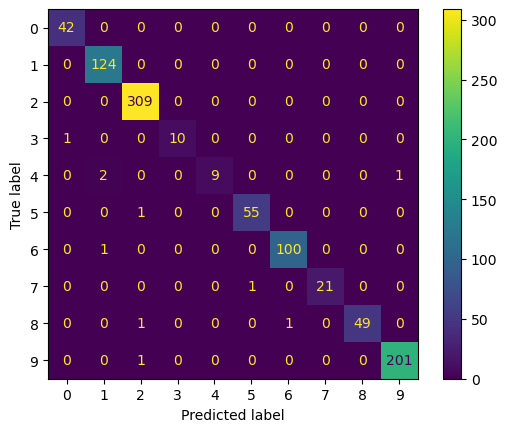

In [158]:
cd3=ConfusionMatrixDisplay(con3)
cd3.plot()

# MODEL-4 KNN

In [159]:
model4=KNeighborsClassifier()

In [160]:
model4.fit(x_train,y_train)

KNeighborsClassifier()

In [161]:
knntrain=model4.score(x_train,y_train)*100
knntrain

77.51152073732719

In [162]:
knntest=model4.score(x_test,y_test)*100
knntest

64.94623655913978

In [163]:
y_pred4=model4.predict(x_test)
y_pred4

array(['Water Retaining Fertilizer', 'Muriate of Potash',
       'Water Retaining Fertilizer', 'Lime', 'DAP', 'Compost', 'DAP',
       'Muriate of Potash', 'DAP', 'Compost',
       'Water Retaining Fertilizer', 'Compost', 'DAP', 'Compost',
       'Compost', 'Water Retaining Fertilizer',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer',
       'Water Retaining Fertilizer', 'Muriate of Potash',
       'Water Retaining Fertilizer', 'Urea', 'DAP',
       'Water Retaining Fertilizer', 'Muriate of Potash',
       'Water Retaining Fertilizer', 'Balanced NPK Fertilizer', 'DAP',
       'DAP', 'Lime', 'Water Retaining Fertilizer', 'Muriate of Potash',
       'DAP', 'Water Retaining Fertilizer', 'DAP', 'Lime', 'DAP', 'DAP',
       'Compost', 'DAP', 'Water Retaining Fertilizer', 'DAP', 'DAP',
       'Organic Fertilizer', 'DAP', 'Water Retaining Fertilizer',
       'Water Retaining Fertilizer', 'DAP', 'DAP', 'Compost', 'DAP',
       'Balanced NPK Fertilizer', 'Urea', 'DAP',
       

In [164]:
y_test

718     Water Retaining Fertilizer
2953             Muriate of Potash
1805                       Compost
1612             Muriate of Potash
1190                           DAP
                   ...            
2971    Water Retaining Fertilizer
2996                       Compost
2282                           DAP
2170                           DAP
844     Water Retaining Fertilizer
Name: Fertilizer, Length: 930, dtype: object

In [165]:
ac4=accuracy_score(y_test,y_pred4)
ac4

0.6494623655913978

In [166]:
con4=confusion_matrix(y_test,y_pred4)
con4

array([[ 32,   2,   0,   0,   0,   0,   0,   0,   0,   8],
       [  4,  83,  16,   1,   0,   0,   3,   1,   0,  16],
       [  1,  12, 265,   0,   0,   5,   9,   6,   1,  10],
       [  1,   1,   3,   1,   0,   1,   2,   0,   0,   2],
       [  1,   1,   4,   0,   4,   0,   0,   0,   0,   2],
       [  0,   6,  22,   1,   0,  14,   6,   4,   0,   3],
       [  1,  13,  26,   0,   3,   5,  40,   3,   0,  10],
       [  1,   0,   3,   0,   0,   3,   3,  10,   0,   2],
       [  0,   2,  26,   0,   0,   0,   4,   1,  14,   4],
       [ 11,  21,  15,   0,   0,   4,   7,   2,   1, 141]])

In [167]:
cr4=classification_report(y_test,y_pred4)
print(cr4)

                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       0.62      0.76      0.68        42
                   Compost       0.59      0.67      0.63       124
                       DAP       0.70      0.86      0.77       309
General Purpose Fertilizer       0.33      0.09      0.14        11
                    Gypsum       0.57      0.33      0.42        12
                      Lime       0.44      0.25      0.32        56
         Muriate of Potash       0.54      0.40      0.46       101
        Organic Fertilizer       0.37      0.45      0.41        22
                      Urea       0.88      0.27      0.42        51
Water Retaining Fertilizer       0.71      0.70      0.70       202

                  accuracy                           0.65       930
                 macro avg       0.57      0.48      0.49       930
              weighted avg       0.65      0.65      0.63       930



# MODEL-5 ADABOOSTCLASSIFIER

In [168]:
model5=AdaBoostClassifier(n_estimators=250,learning_rate=0.3,random_state=1)

In [169]:
model5.fit(x_train,y_train)

AdaBoostClassifier(learning_rate=0.3, n_estimators=250, random_state=1)

In [170]:
Adatrain=model5.score(x_train,y_train)*100
Adatrain

76.17511520737327

In [171]:
Aadtest=model5.score(x_test,y_test)*100
Aadtest

74.83870967741936

In [172]:
y_pred5=model5.predict(x_test)


In [173]:
y_test

718     Water Retaining Fertilizer
2953             Muriate of Potash
1805                       Compost
1612             Muriate of Potash
1190                           DAP
                   ...            
2971    Water Retaining Fertilizer
2996                       Compost
2282                           DAP
2170                           DAP
844     Water Retaining Fertilizer
Name: Fertilizer, Length: 930, dtype: object

In [174]:
y_test

718     Water Retaining Fertilizer
2953             Muriate of Potash
1805                       Compost
1612             Muriate of Potash
1190                           DAP
                   ...            
2971    Water Retaining Fertilizer
2996                       Compost
2282                           DAP
2170                           DAP
844     Water Retaining Fertilizer
Name: Fertilizer, Length: 930, dtype: object

In [175]:
ac5=accuracy_score(y_test,y_pred5)
ac5

0.7483870967741936

In [176]:
con5=confusion_matrix(y_test,y_pred5)
con5

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,  42],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 124],
       [  0,   0, 309,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  11],
       [  0,   0,   0,   0,  11,   0,   0,   0,   0,   1],
       [  0,   0,   1,   0,   0,  55,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0, 100,   0,   0,   1],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  22],
       [  0,   0,  25,   0,   0,   0,   6,   0,  20,   0],
       [  0,   0,   1,   0,   0,   0,   0,   0,   0, 201]])

In [177]:
cr5=classification_report(y_test,y_pred5)
print(cr5)

                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       0.00      0.00      0.00        42
                   Compost       0.00      0.00      0.00       124
                       DAP       0.92      1.00      0.96       309
General Purpose Fertilizer       0.00      0.00      0.00        11
                    Gypsum       1.00      0.92      0.96        12
                      Lime       1.00      0.98      0.99        56
         Muriate of Potash       0.94      0.99      0.97       101
        Organic Fertilizer       0.00      0.00      0.00        22
                      Urea       1.00      0.39      0.56        51
Water Retaining Fertilizer       0.50      1.00      0.67       202

                  accuracy                           0.75       930
                 macro avg       0.54      0.53      0.51       930
              weighted avg       0.64      0.75      0.67       930



# MODEL-6 GRADIENTBOOSTING

In [178]:
model6=GradientBoostingClassifier(n_estimators=250,learning_rate=0.3,random_state=1)

In [179]:
model6.fit(x_train,y_train)

GradientBoostingClassifier(learning_rate=0.3, n_estimators=250, random_state=1)

In [180]:
gradienttrain=model6.score(x_train,y_train)*100
gradienttrain

100.0

In [181]:
gradienttest=model6.score(x_test,y_test)*100
gradienttest

99.13978494623656

In [182]:
y_pred6=model6.predict(x_test)
y_pred6

array(['Water Retaining Fertilizer', 'Muriate of Potash', 'Compost',
       'Muriate of Potash', 'DAP', 'DAP', 'DAP', 'DAP', 'DAP', 'Compost',
       'Water Retaining Fertilizer', 'Urea', 'DAP', 'Compost',
       'Balanced NPK Fertilizer', 'DAP', 'Muriate of Potash',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer',
       'Water Retaining Fertilizer', 'DAP', 'Muriate of Potash',
       'Organic Fertilizer', 'Water Retaining Fertilizer',
       'Balanced NPK Fertilizer', 'DAP', 'DAP', 'Lime',
       'Water Retaining Fertilizer', 'Lime', 'DAP',
       'Water Retaining Fertilizer', 'Lime', 'Muriate of Potash', 'DAP',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer', 'DAP',
       'Compost', 'DAP', 'DAP', 'Organic Fertilizer', 'DAP',
       'Water Retaining Fertilizer', 'Water Retaining Fertilizer', 'DAP',
       'DAP', 'Compost', 'Lime', 'Balanced NPK Fertilizer', 'DAP', 'DAP',
       'Ba

In [183]:
y_test

718     Water Retaining Fertilizer
2953             Muriate of Potash
1805                       Compost
1612             Muriate of Potash
1190                           DAP
                   ...            
2971    Water Retaining Fertilizer
2996                       Compost
2282                           DAP
2170                           DAP
844     Water Retaining Fertilizer
Name: Fertilizer, Length: 930, dtype: object

In [184]:
ac6=accuracy_score(y_test,y_pred6)
ac6

0.9913978494623656

In [185]:
con6=confusion_matrix(y_test,y_pred6)
con6

array([[ 42,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, 123,   0,   0,   0,   0,   0,   0,   0,   1],
       [  0,   0, 309,   0,   0,   0,   0,   0,   0,   0],
       [  2,   0,   0,   9,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,  11,   0,   0,   0,   0,   1],
       [  0,   0,   1,   0,   0,  55,   0,   0,   0,   0],
       [  0,   1,   0,   0,   1,   0,  99,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  22,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  51,   0],
       [  0,   0,   1,   0,   0,   0,   0,   0,   0, 201]])

In [186]:
cr6=classification_report(y_test,y_pred6)
print(cr6)

                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       0.95      1.00      0.98        42
                   Compost       0.99      0.99      0.99       124
                       DAP       0.99      1.00      1.00       309
General Purpose Fertilizer       1.00      0.82      0.90        11
                    Gypsum       0.92      0.92      0.92        12
                      Lime       1.00      0.98      0.99        56
         Muriate of Potash       1.00      0.98      0.99       101
        Organic Fertilizer       1.00      1.00      1.00        22
                      Urea       1.00      1.00      1.00        51
Water Retaining Fertilizer       0.99      1.00      0.99       202

                  accuracy                           0.99       930
                 macro avg       0.98      0.97      0.98       930
              weighted avg       0.99      0.99      0.99       930



# Representing Models Training and Testing Score Graphically

In [187]:
score=pd.DataFrame({"Model":['Logistic Regression','DecisionTreeClassifier','RandomForestClassifier',
                           'KNeighborClassifier','AdaBoostClassifier','GradientBoostClassifier'],
                    "TrainingScores":[logtrain,decisiontrain,randomtrain,knntrain,Adatrain,gradienttrain],
                    "TestingScores":[logtest,decisiontest,randomtest,knntest,Aadtest,gradienttest]})
score
                    

,Model,TrainingScores,TestingScores
0,Logistic Regression,81.382488,79.139785
1,DecisionTreeClassifier,100.000000,99.354839
2,RandomForestClassifier,100.000000,98.924731
3,KNeighborClassifier,77.511521,64.946237
4,AdaBoostClassifier,76.175115,74.838710
5,GradientBoostClassifier,100.000000,99.139785


# Models and training score-Bar chart

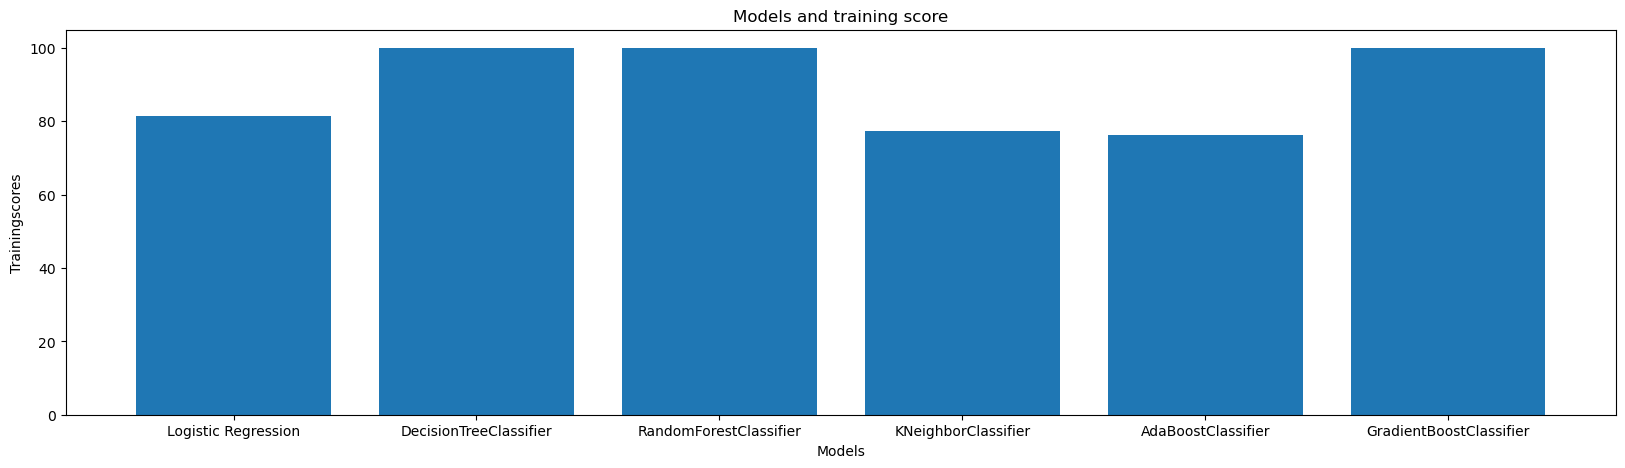

In [188]:
x=score.Model
y=score.TrainingScores
plt.figure(figsize=(20,5))
plt.bar(x,y)
plt.xlabel("Models")
plt.ylabel("Trainingscores")
plt.title("Models and training score")
plt.show()
           

# Model and TestingScores-Bar chart

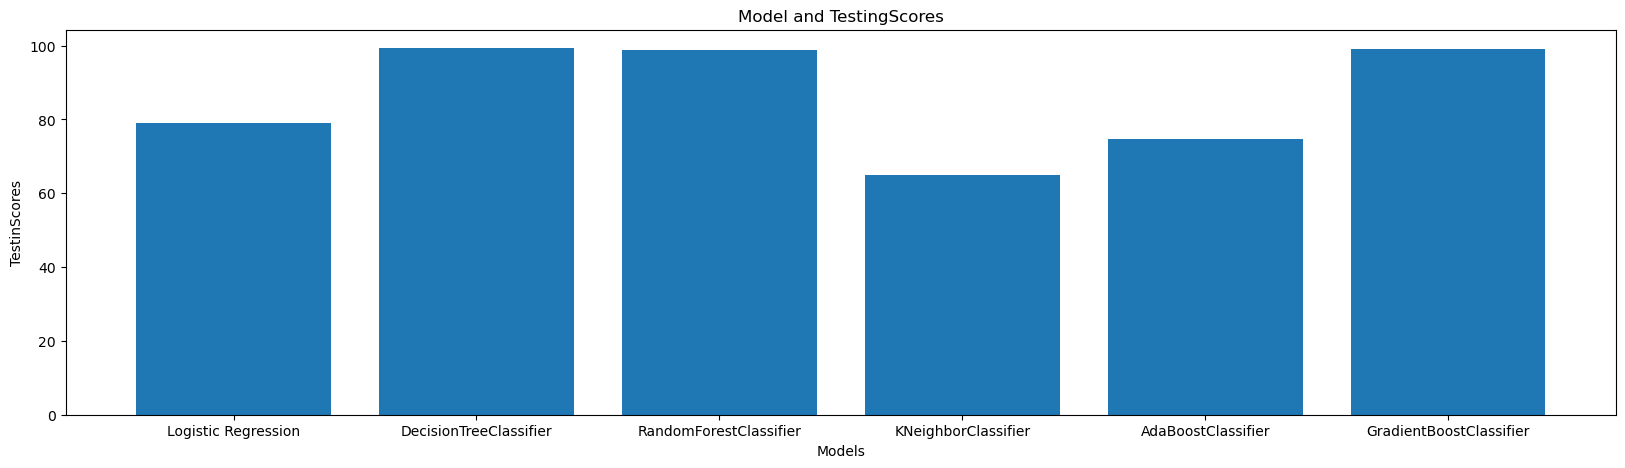

In [189]:
x=score.Model
y=score.TestingScores
plt.figure(figsize=(20,5))
plt.bar(x,y)
plt.xlabel("Models")
plt.ylabel("TestinScores")
plt.title("Model and TestingScores")
plt.show()

In [191]:
with open('model.pkl', 'wb') as file:
    pickle.dump(model3, file)


with open('model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)
    
print(loaded_model.predict(x_test))

['Water Retaining Fertilizer' 'Muriate of Potash' 'Compost'
 'Muriate of Potash' 'DAP' 'DAP' 'DAP' 'DAP' 'DAP' 'Compost'
 'Water Retaining Fertilizer' 'Urea' 'DAP' 'Compost'
 'Balanced NPK Fertilizer' 'DAP' 'Muriate of Potash'
 'Water Retaining Fertilizer' 'Water Retaining Fertilizer'
 'Water Retaining Fertilizer' 'Water Retaining Fertilizer'
 'Water Retaining Fertilizer' 'DAP' 'Muriate of Potash'
 'Organic Fertilizer' 'Water Retaining Fertilizer'
 'Balanced NPK Fertilizer' 'DAP' 'DAP' 'Lime' 'Water Retaining Fertilizer'
 'Lime' 'DAP' 'Water Retaining Fertilizer' 'Lime' 'Muriate of Potash'
 'DAP' 'Water Retaining Fertilizer' 'Water Retaining Fertilizer' 'DAP'
 'Compost' 'DAP' 'DAP' 'Organic Fertilizer' 'DAP'
 'Water Retaining Fertilizer' 'Compost' 'DAP' 'DAP' 'Compost' 'Lime'
 'Balanced NPK Fertilizer' 'DAP' 'DAP' 'Balanced NPK Fertilizer'
 'Water Retaining Fertilizer' 'Compost' 'DAP' 'DAP' 'DAP' 'DAP' 'Gypsum'
 'Balanced NPK Fertilizer' 'Lime' 'Urea' 'Compost'
 'Water Retaining Fertil

In [ ]:

    
print(loaded_model.predict(x_test))